In [1]:
from bbq.field import Field
from bbq.polynomial import Monomial
from bbq.bbq_code import BivariateBicycle
from bbq.decoder import RelayBP, BPOSD, BP, StrawBP
from bbq.simulation import process_results
from bbq.circuit import construct_sm_circuit, generate_noisy_circuit, simulate_x_circuit, generate_single_error_circuits, build_hx_dict, build_hz_dict, build_hx_eff, build_hz_eff, construct_decoding_matrix

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from relay_bp import RelayDecoderF32


## Part II: Surface Code under Code Capacity against HDRG

For qutrit toric code - need to show threshold is better than around 11.8% (HDRG)

In [ ]:
relaybp = {}
relaybp_tr = {}
relaybp['5'] = [144, 284, 642, 1367, 3104, 8774, 19085, 60058, 102508, 39718]
relaybp_tr['5'] = [100, 100, 100, 100, 100, 100, 100, 100, 80, 13]
relaybp['7'] = [131, 236, 466, 2018, 7291, 16850, 46942, 30602, 0, 0]
relaybp_tr['7'] = [100, 100, 100, 100, 100, 60, 40, 10, 0, 0]
relaybp['9'] = [81, 136, 385, 1328, 6609, 17607, 0, 0, 0, 0]
relaybp_tr['9'] = [70, 70, 70, 70, 70, 35, 0, 0, 0, 0]

bposd = {}
bposd_tr = {}
bposd['5'] = [158, 279, 620, 1265, 3008, 7786, 20476, 57696, 98395, 39718]
bposd_tr['5'] = [100, 100, 100, 100, 100, 100, 100, 100, 80, 10]
bposd['7'] = [150, 275, 513, 2075, 7668, 18661, 59057, 41252, 0, 0]
bposd_tr['7'] = [100, 100, 100, 100, 100, 60, 40, 10, 0, 0]
bposd['9'] = [98, 169, 478, 2628, 13049, 31228, 0, 0, 0, 0]
bposd_tr['9'] = [70, 70, 70, 70, 70, 35, 0, 0, 0, 0]

bp = {}
bp_tr = {}
bp['5'] = [130, 215, 371, 738, 1170, 1932, 3720, 7405, 8780, 12674]
bp_tr['5'] = [100, 100, 100, 100, 100, 100, 100, 100, 80, 60]
bp['7'] = [124, 168, 295, 672, 1236, 1427, 1807, 575, 0, 0]
bp_tr['7'] = [100, 100, 100, 100, 100, 60, 40, 10, 0, 0]
bp['9'] = [79, 117, 158, 398, 864, 547, 0, 0, 0, 0]
bp_tr['9'] = [70, 70, 70, 70, 70, 35, 0, 0, 0, 0]


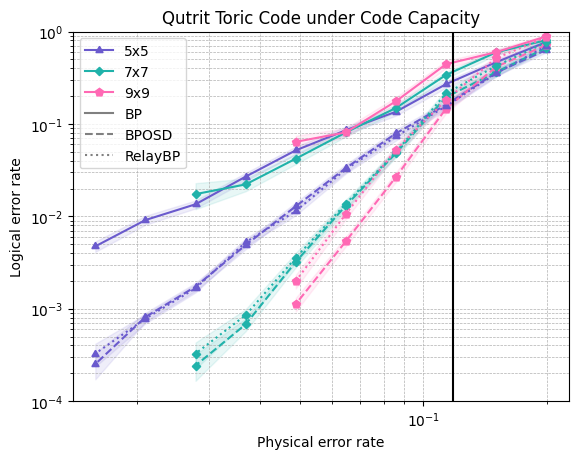

In [121]:
legend_elements = [
    Line2D([0], [0], color='slateblue', marker=(3, 0, 0), linestyle='-', label='5x5'),
    Line2D([0], [0], color='lightseagreen', marker=(4, 0, 0), linestyle='-', label='7x7'),
    Line2D([0], [0], color='hotpink', marker=(5, 0, 0), linestyle='-', label='9x9'),
    Line2D([0], [0], color='grey', linestyle='-', label='BP'),
    Line2D([0], [0], color='grey', linestyle='--', label='BPOSD'),
    Line2D([0], [0], color='grey', linestyle=':', label='RelayBP'),
]

physical_error = np.logspace(-0.7, -1.8, 10)
plot_bp, errors_bp = process_results(bp, bp_tr, "code_capacity")
plot_bposd, errors_bposd = process_results(bposd, bposd_tr, "code_capacity")
plot_relaybp, errors_relaybp = process_results(relaybp, relaybp_tr, "code_capacity")
alpha = 0.1

fig, ax = plt.subplots()

ax.loglog(physical_error, plot_bp['5'], color='slateblue', marker=(3, 0, 0))
ax.loglog(physical_error, plot_bp['7'], color='lightseagreen', marker=(4, 0, 0))
ax.loglog(physical_error, plot_bp['9'], color='hotpink', marker=(5, 0, 0))
ax.fill_between(physical_error, plot_bp['5'] - errors_bp['5'], plot_bp['5'] + errors_bp['5'], color='slateblue', alpha=alpha)
ax.fill_between(physical_error, plot_bp['7'] - errors_bp['7'], plot_bp['7'] + errors_bp['7'], color='lightseagreen', alpha=alpha)
ax.fill_between(physical_error, plot_bp['9'] - errors_bp['9'], plot_bp['9'] + errors_bp['9'], color='hotpink', alpha=alpha)

ax.loglog(physical_error, plot_bposd['5'], color='slateblue', marker=(3, 0, 0), linestyle='--')
ax.loglog(physical_error, plot_bposd['7'], color='lightseagreen', marker=(4, 0, 0), linestyle='--')
ax.loglog(physical_error, plot_bposd['9'], color='hotpink', marker=(5, 0, 0), linestyle='--')
ax.fill_between(physical_error, plot_bposd['5'] - errors_bposd['5'], plot_bposd['5'] + errors_bposd['5'], color='slateblue', alpha=alpha)
ax.fill_between(physical_error, plot_bposd['7'] - errors_bposd['7'], plot_bposd['7'] + errors_bposd['7'], color='lightseagreen', alpha=alpha)
ax.fill_between(physical_error, plot_bposd['9'] - errors_bposd['9'], plot_bposd['9'] + errors_bposd['9'], color='hotpink', alpha=alpha)

ax.loglog(physical_error, plot_relaybp['5'], color='slateblue', marker=(3, 0, 0), linestyle=':')
ax.loglog(physical_error, plot_relaybp['7'], color='lightseagreen', marker=(4, 0, 0), linestyle=':')
ax.loglog(physical_error, plot_relaybp['9'], color='hotpink', marker=(5, 0, 0), linestyle=':')
ax.fill_between(physical_error, plot_relaybp['5'] - errors_relaybp['5'], plot_relaybp['5'] + errors_relaybp['5'], color='slateblue', alpha=alpha)
ax.fill_between(physical_error, plot_relaybp['7'] - errors_relaybp['7'], plot_relaybp['7'] + errors_relaybp['7'], color='lightseagreen', alpha=alpha)
ax.fill_between(physical_error, plot_relaybp['9'] - errors_relaybp['9'], plot_relaybp['9'] + errors_relaybp['9'], color='hotpink', alpha=alpha)

ax.plot([0.118, 0.118], [0, 1], color='black')

ax.set_xlabel('Physical error rate')
ax.set_ylabel('Logical error rate')
ax.set_ylim(0.0001, 1)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(handles=legend_elements)
ax.set_title('Qutrit Toric Code under Code Capacity');


In [155]:
thresh_bp = {}
bp_tr = {'3':500, '5':500, '7':500, '9':500}
thresh_bp['3'] = [964, 1297, 2239]
thresh_bp['5'] = [809, 1191, 2429]
thresh_bp['7'] = [702, 1033, 2246]
thresh_bp['9'] = [618, 900, 1868]

thresh_bposd = {}
bposd_tr = {'3':500, '5':500, '7':500, '9':500}
thresh_bposd['3'] = [1097, 1525, 2936]
thresh_bposd['5'] = [987, 1587, 3882]
thresh_bposd['7'] = [890, 1695, 5607]
thresh_bposd['9'] = [785, 1707, 7528]

thresh_relaybp = {}
relaybp_tr = {'3':500, '5':500, '7':500, '9':500}
thresh_relaybp['3'] = [1057, 1569, 2941]
thresh_relaybp['5'] = [938, 1536, 4011]
thresh_relaybp['7'] = [767, 1438, 5109]
thresh_relaybp['9'] = [616, 1124, 4931]


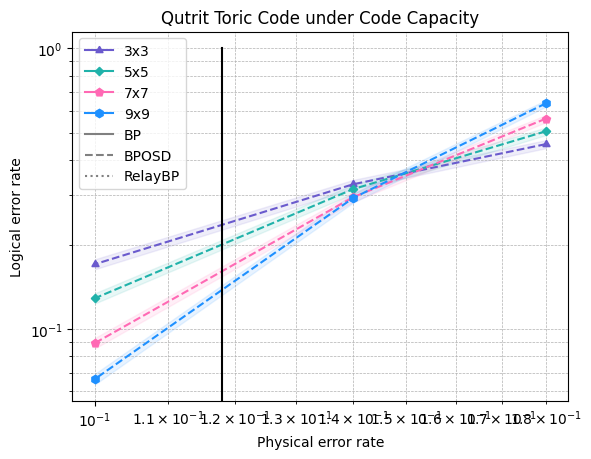

In [167]:
legend_elements = [
    Line2D([0], [0], color='slateblue', marker=(3, 0, 0), linestyle='-', label='3x3'),
    Line2D([0], [0], color='lightseagreen', marker=(4, 0, 0), linestyle='-', label='5x5'),
    Line2D([0], [0], color='hotpink', marker=(5, 0, 0), linestyle='-', label='7x7'),
    Line2D([0], [0], color='dodgerblue', marker=(6, 0, 0), linestyle='-', label='9x9'),
    Line2D([0], [0], color='grey', linestyle='-', label='BP'),
    Line2D([0], [0], color='grey', linestyle='--', label='BPOSD'),
    Line2D([0], [0], color='grey', linestyle=':', label='RelayBP'),
]

physical_error =[0.18, 0.14, 0.1]
plot_bp, errors_bp = process_results(thresh_bp, bp_tr, "code_capacity")
plot_bposd, errors_bposd = process_results(thresh_bposd, bposd_tr, "code_capacity")
plot_relaybp, errors_relaybp = process_results(thresh_relaybp, relaybp_tr, "code_capacity")
alpha = 0.1

fig, ax = plt.subplots()

# ax.loglog(physical_error, plot_bp['3'], color='slateblue', marker=(3, 0, 0))
# ax.loglog(physical_error, plot_bp['5'], color='lightseagreen', marker=(4, 0, 0))
# ax.loglog(physical_error, plot_bp['7'], color='hotpink', marker=(5, 0, 0))
# ax.loglog(physical_error, plot_bp['9'], color='dodgerblue', marker=(6, 0, 0))
# ax.fill_between(physical_error, plot_bp['3'] - errors_bp['3'], plot_bp['3'] + errors_bp['3'], color='slateblue', alpha=alpha)
# ax.fill_between(physical_error, plot_bp['5'] - errors_bp['5'], plot_bp['5'] + errors_bp['5'], color='lightseagreen', alpha=alpha)
# ax.fill_between(physical_error, plot_bp['7'] - errors_bp['7'], plot_bp['7'] + errors_bp['7'], color='hotpink', alpha=alpha)
# ax.fill_between(physical_error, plot_bp['9'] - errors_bp['9'], plot_bp['9'] + errors_bp['9'], color='dodgerblue', alpha=alpha)

ax.loglog(physical_error, plot_bposd['3'], color='slateblue', marker=(3, 0, 0), linestyle='--')
ax.loglog(physical_error, plot_bposd['5'], color='lightseagreen', marker=(4, 0, 0), linestyle='--')
ax.loglog(physical_error, plot_bposd['7'], color='hotpink', marker=(5, 0, 0), linestyle='--')
ax.loglog(physical_error, plot_bposd['9'], color='dodgerblue', marker=(6, 0, 0), linestyle='--')
ax.fill_between(physical_error, plot_bposd['3'] - errors_bposd['3'], plot_bposd['3'] + errors_bposd['3'], color='slateblue', alpha=alpha)
ax.fill_between(physical_error, plot_bposd['5'] - errors_bposd['5'], plot_bposd['5'] + errors_bposd['5'], color='lightseagreen', alpha=alpha)
ax.fill_between(physical_error, plot_bposd['7'] - errors_bposd['7'], plot_bposd['7'] + errors_bposd['7'], color='hotpink', alpha=alpha)
ax.fill_between(physical_error, plot_bposd['9'] - errors_bposd['9'], plot_bposd['9'] + errors_bposd['9'], color='dodgerblue', alpha=alpha)

# ax.loglog(physical_error, plot_relaybp['3'], color='slateblue', marker=(3, 0, 0), linestyle=':')
# ax.loglog(physical_error, plot_relaybp['5'], color='lightseagreen', marker=(4, 0, 0), linestyle=':')
# ax.loglog(physical_error, plot_relaybp['7'], color='hotpink', marker=(5, 0, 0), linestyle=':')
# ax.loglog(physical_error, plot_relaybp['9'], color='dodgerblue', marker=(6, 0, 0), linestyle=':')
# ax.fill_between(physical_error, plot_relaybp['3'] - errors_relaybp['3'], plot_relaybp['3'] + errors_relaybp['3'], color='slateblue', alpha=alpha)
# ax.fill_between(physical_error, plot_relaybp['5'] - errors_relaybp['5'], plot_relaybp['5'] + errors_relaybp['5'], color='lightseagreen', alpha=alpha)
# ax.fill_between(physical_error, plot_relaybp['7'] - errors_relaybp['7'], plot_relaybp['7'] + errors_relaybp['7'], color='hotpink', alpha=alpha)
# ax.fill_between(physical_error, plot_relaybp['9'] - errors_relaybp['9'], plot_relaybp['9'] + errors_relaybp['9'], color='dodgerblue', alpha=alpha)

ax.plot([0.118, 0.118], [0, 1], color='black')

ax.set_xlabel('Physical error rate')
ax.set_ylabel('Logical error rate')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(handles=legend_elements)
ax.set_title('Qutrit Toric Code under Code Capacity');


#### 5x5

In [ ]:
# Code setup
d = 3
field = Field(3)
x, y = Monomial(field, 'x'), Monomial(field, 'y')
a, b = 1 - x, 1 - y

bb = BivariateBicycle(a, b, d, d, 1)
hx, hz = bb.hx, bb.hz
lx, lz = bb.x_logicals, bb.z_logicals

# BP parameters
bp_max_iter = 300

# BPOSD parameters
osd_order = 0

# RelayBP parameters
max_iter = 60
first_iter = 80
solutions = 1
relays = 5
centre = 0.05
width = 0.1

# StrawBP parameters


# physical_error = np.logspace(-0.7, -1.8, 10)
# num_failures = [100, 100, 100, 100, 100, 100, 100, 100, 80, 60]

physical_error =[0.18, 0.14, 0.1]
num_failures = [500, 500, 500]

print(f'Physical error rate: {physical_error}')


Physical error rate: [0.18, 0.14, 0.1]


In [144]:
print(f'Simulation for error rates {physical_error}')

results_relaybp = []
results_bposd = []
results_bp = []

for ind, p in enumerate(physical_error):
    print(f'Starting trials for p={p:.2f}')

    np.random.seed(27)

    n_qudits = hx.shape[1]
    channel_prob_x = np.ones(n_qudits) * p
    x_prior = np.zeros((n_qudits, field.p), dtype=float)

    for i, prob in enumerate(channel_prob_x):
        x_prior[i, 0] = 1 - prob
        for j in range(1, field.p):
            x_prior[i, j] = prob / (field.p - 1)

    failures_relaybp = 0
    failures_bposd = 0
    failures_bp = 0
    failures = sum([failures_relaybp, failures_bposd, failures_bp])

    trials = 0

    while failures < 3 * num_failures[ind]:
        trials += 1

        mem_weight = np.zeros((n_qudits, field.p, relays))
        mem_weight[:, :, 0] = centre
        mem_weight[:, :, 1:] = np.random.uniform(centre - width/2, centre + width/2, size=(n_qudits, field.p, relays - 1))

        # Generate syndrome
        error = np.zeros(n_qudits, dtype=int)
        error_mask = np.random.rand(n_qudits) < p
        for i in np.where(error_mask)[0]:
            error[i] = np.random.randint(1, field.p)
        syndrome = (hx @ error) % field.p

        # Decode
        if failures_bp < num_failures[ind]:
            bp = BP(field, hx, x_prior, bp_max_iter)
            guessed_error, decoder_success, bp_success, posterior = bp.decode(syndrome, debug=True, metric=False)
            error_difference = (error - guessed_error) % field.p
            logical_effect = (np.array(lx) @ error_difference) % field.p

            if np.any(logical_effect != 0):
                failures_bp += 1

            if failures_bp == num_failures[ind]:
                results_bp.append(trials)
                print(f'Completed BP: {trials}')

        if failures_bposd < num_failures[ind]:
            bposd = BPOSD(field, hx, x_prior, bp_max_iter)
            guessed_error, decoder_success, bp_success, posterior = bposd.decode(syndrome, debug=True, metric=False)
            error_difference = (error - guessed_error) % field.p
            logical_effect = (np.array(lx) @ error_difference) % field.p

            if np.any(logical_effect != 0):
                failures_bposd += 1

            if failures_bposd == num_failures[ind]:
                results_bposd.append(trials)
                print(f'Completed BPOSD: {trials}')

        if failures_relaybp < num_failures[ind]:
            relaybp = RelayBP(field, hx, x_prior, max_iter=max_iter, first_iter=first_iter, solutions=solutions, relays=relays, mem_weight=mem_weight)
            guessed_error, decoder_success, posterior = relaybp.decode(syndrome, debug=True, metric=False)
            error_difference = (error - guessed_error) % field.p
            logical_effect = (np.array(lx) @ error_difference) % field.p

            if np.any(logical_effect != 0):
                failures_relaybp += 1

            if failures_relaybp == num_failures[ind]:
                results_relaybp.append(trials)
                print(f'Completed RelayBP: {trials}')

        if trials % 100 == 0:
            print(f'UPDATE: {trials} trials reached.')

        failures = sum([failures_relaybp, failures_bposd, failures_bp])
    print(f'[{ind+1}/{len(physical_error)}]')


Simulation for error rates [0.18, 0.14, 0.1]
Starting trials for p=0.18
UPDATE: 100 trials reached.
UPDATE: 200 trials reached.
UPDATE: 300 trials reached.
UPDATE: 400 trials reached.
UPDATE: 500 trials reached.
UPDATE: 600 trials reached.
UPDATE: 700 trials reached.
UPDATE: 800 trials reached.
UPDATE: 900 trials reached.
Completed BP: 964
UPDATE: 1000 trials reached.
Completed RelayBP: 1057
Completed BPOSD: 1097
[1/3]
Starting trials for p=0.14
UPDATE: 100 trials reached.
UPDATE: 200 trials reached.
UPDATE: 300 trials reached.
UPDATE: 400 trials reached.
UPDATE: 500 trials reached.
UPDATE: 600 trials reached.
UPDATE: 700 trials reached.
UPDATE: 800 trials reached.
UPDATE: 900 trials reached.
UPDATE: 1000 trials reached.
UPDATE: 1100 trials reached.
UPDATE: 1200 trials reached.
Completed BP: 1297
UPDATE: 1300 trials reached.
UPDATE: 1400 trials reached.
UPDATE: 1500 trials reached.
Completed BPOSD: 1525
Completed RelayBP: 1569
[2/3]
Starting trials for p=0.10
UPDATE: 100 trials reached

In [145]:
results_bp, results_bposd, results_relaybp


([964, 1297, 2239], [1097, 1525, 2936], [1057, 1569, 2941])

In [146]:
# Code setup
d = 5
field = Field(3)
x, y = Monomial(field, 'x'), Monomial(field, 'y')
a, b = 1 - x, 1 - y

bb = BivariateBicycle(a, b, d, d, 1)
hx, hz = bb.hx, bb.hz
lx, lz = bb.x_logicals, bb.z_logicals

# BP parameters
bp_max_iter = 300

# BPOSD parameters
osd_order = 0

# RelayBP parameters
max_iter = 60
first_iter = 80
solutions = 1
relays = 5
centre = 0.05
width = 0.1

# StrawBP parameters


# physical_error = np.logspace(-0.7, -1.8, 10)
# num_failures = [100, 100, 100, 100, 100, 100, 100, 100, 80, 60]

physical_error =[0.18, 0.14, 0.1]
num_failures = [500, 500, 500]

print(f'Physical error rate: {physical_error}')


Physical error rate: [0.18, 0.14, 0.1]


In [147]:
print(f'Simulation for error rates {physical_error}')

results_relaybp = []
results_bposd = []
results_bp = []

for ind, p in enumerate(physical_error):
    print(f'Starting trials for p={p:.2f}')

    np.random.seed(27)

    n_qudits = hx.shape[1]
    channel_prob_x = np.ones(n_qudits) * p
    x_prior = np.zeros((n_qudits, field.p), dtype=float)

    for i, prob in enumerate(channel_prob_x):
        x_prior[i, 0] = 1 - prob
        for j in range(1, field.p):
            x_prior[i, j] = prob / (field.p - 1)

    failures_relaybp = 0
    failures_bposd = 0
    failures_bp = 0
    failures = sum([failures_relaybp, failures_bposd, failures_bp])

    trials = 0

    while failures < 3 * num_failures[ind]:
        trials += 1

        mem_weight = np.zeros((n_qudits, field.p, relays))
        mem_weight[:, :, 0] = centre
        mem_weight[:, :, 1:] = np.random.uniform(centre - width/2, centre + width/2, size=(n_qudits, field.p, relays - 1))

        # Generate syndrome
        error = np.zeros(n_qudits, dtype=int)
        error_mask = np.random.rand(n_qudits) < p
        for i in np.where(error_mask)[0]:
            error[i] = np.random.randint(1, field.p)
        syndrome = (hx @ error) % field.p

        # Decode
        if failures_bp < num_failures[ind]:
            bp = BP(field, hx, x_prior, bp_max_iter)
            guessed_error, decoder_success, bp_success, posterior = bp.decode(syndrome, debug=True, metric=False)
            error_difference = (error - guessed_error) % field.p
            logical_effect = (np.array(lx) @ error_difference) % field.p

            if np.any(logical_effect != 0):
                failures_bp += 1

            if failures_bp == num_failures[ind]:
                results_bp.append(trials)
                print(f'Completed BP: {trials}')

        if failures_bposd < num_failures[ind]:
            bposd = BPOSD(field, hx, x_prior, bp_max_iter)
            guessed_error, decoder_success, bp_success, posterior = bposd.decode(syndrome, debug=True, metric=False)
            error_difference = (error - guessed_error) % field.p
            logical_effect = (np.array(lx) @ error_difference) % field.p

            if np.any(logical_effect != 0):
                failures_bposd += 1

            if failures_bposd == num_failures[ind]:
                results_bposd.append(trials)
                print(f'Completed BPOSD: {trials}')

        if failures_relaybp < num_failures[ind]:
            relaybp = RelayBP(field, hx, x_prior, max_iter=max_iter, first_iter=first_iter, solutions=solutions, relays=relays, mem_weight=mem_weight)
            guessed_error, decoder_success, posterior = relaybp.decode(syndrome, debug=True, metric=False)
            error_difference = (error - guessed_error) % field.p
            logical_effect = (np.array(lx) @ error_difference) % field.p

            if np.any(logical_effect != 0):
                failures_relaybp += 1

            if failures_relaybp == num_failures[ind]:
                results_relaybp.append(trials)
                print(f'Completed RelayBP: {trials}')

        if trials % 100 == 0:
            print(f'UPDATE: {trials} trials reached.')

        failures = sum([failures_relaybp, failures_bposd, failures_bp])
    print(f'[{ind+1}/{len(physical_error)}]')


Simulation for error rates [0.18, 0.14, 0.1]
Starting trials for p=0.18
UPDATE: 100 trials reached.
UPDATE: 200 trials reached.
UPDATE: 300 trials reached.
UPDATE: 400 trials reached.
UPDATE: 500 trials reached.
UPDATE: 600 trials reached.
UPDATE: 700 trials reached.
UPDATE: 800 trials reached.
Completed BP: 809
UPDATE: 900 trials reached.
Completed RelayBP: 938
Completed BPOSD: 987
[1/3]
Starting trials for p=0.14
UPDATE: 100 trials reached.
UPDATE: 200 trials reached.
UPDATE: 300 trials reached.
UPDATE: 400 trials reached.
UPDATE: 500 trials reached.
UPDATE: 600 trials reached.
UPDATE: 700 trials reached.
UPDATE: 800 trials reached.
UPDATE: 900 trials reached.
UPDATE: 1000 trials reached.
UPDATE: 1100 trials reached.
Completed BP: 1191
UPDATE: 1200 trials reached.
UPDATE: 1300 trials reached.
UPDATE: 1400 trials reached.
UPDATE: 1500 trials reached.
Completed RelayBP: 1536
Completed BPOSD: 1587
[2/3]
Starting trials for p=0.10
UPDATE: 100 trials reached.
UPDATE: 200 trials reached.
U

In [148]:
results_bp, results_bposd, results_relaybp


([809, 1191, 2429], [987, 1587, 3882], [938, 1536, 4011])

#### 7x7

In [149]:
# Code setup
d = 7
field = Field(3)
x, y = Monomial(field, 'x'), Monomial(field, 'y')
a, b = 1 - x, 1 - y

bb = BivariateBicycle(a, b, d, d, 1)
hx, hz = bb.hx, bb.hz
lx, lz = bb.x_logicals, bb.z_logicals

# BP parameters
bp_max_iter = 300

# BPOSD parameters
osd_order = 0

# RelayBP parameters
max_iter = 60
first_iter = 80
solutions = 1
relays = 5
centre = 0.05
width = 0.1

# StrawBP parameters


# physical_error = np.logspace(-0.7, -1.8, 10)
# num_failures = [100, 100, 100, 100, 100, 100, 100, 100, 80, 60]

physical_error =[0.18, 0.14, 0.1]
num_failures = [500, 500, 500]

print(f'Physical error rate: {physical_error}')


Physical error rate: [0.18, 0.14, 0.1]


In [150]:
print(f'Simulation for error rates {physical_error}')

results_relaybp = []
results_bposd = []
results_bp = []

for ind, p in enumerate(physical_error):
    print(f'Starting trials for p={p:.2f}')

    np.random.seed(27)

    n_qudits = hx.shape[1]
    channel_prob_x = np.ones(n_qudits) * p
    x_prior = np.zeros((n_qudits, field.p), dtype=float)

    for i, prob in enumerate(channel_prob_x):
        x_prior[i, 0] = 1 - prob
        for j in range(1, field.p):
            x_prior[i, j] = prob / (field.p - 1)

    failures_relaybp = 0
    failures_bposd = 0
    failures_bp = 0


    failures = sum([failures_relaybp, failures_bposd, failures_bp])

    trials = 0

    while failures < 3 * num_failures[ind]:
        trials += 1

        mem_weight = np.zeros((n_qudits, field.p, relays))
        mem_weight[:, :, 0] = centre
        mem_weight[:, :, 1:] = np.random.uniform(centre - width/2, centre + width/2, size=(n_qudits, field.p, relays - 1))

        # Generate syndrome
        error = np.zeros(n_qudits, dtype=int)
        error_mask = np.random.rand(n_qudits) < p
        for i in np.where(error_mask)[0]:
            error[i] = np.random.randint(1, field.p)
        syndrome = (hx @ error) % field.p

        # Decode
        if failures_bp < num_failures[ind]:
            bp = BP(field, hx, x_prior, bp_max_iter)
            guessed_error, decoder_success, bp_success, posterior = bp.decode(syndrome, debug=True, metric=False)
            error_difference = (error - guessed_error) % field.p
            logical_effect = (np.array(lx) @ error_difference) % field.p

            if np.any(logical_effect != 0):
                failures_bp += 1

            if failures_bp == num_failures[ind]:
                results_bp.append(trials)
                print(f'Completed BP: {trials}')

        if failures_bposd < num_failures[ind]:
            bposd = BPOSD(field, hx, x_prior, bp_max_iter)
            guessed_error, decoder_success, bp_success, posterior = bposd.decode(syndrome, debug=True, metric=False)
            error_difference = (error - guessed_error) % field.p
            logical_effect = (np.array(lx) @ error_difference) % field.p

            if np.any(logical_effect != 0):
                failures_bposd += 1

            if failures_bposd == num_failures[ind]:
                results_bposd.append(trials)
                print(f'Completed BPOSD: {trials}')

        if failures_relaybp < num_failures[ind]:
            relaybp = RelayBP(field, hx, x_prior, max_iter=max_iter, first_iter=first_iter, solutions=solutions, relays=relays, mem_weight=mem_weight)
            guessed_error, decoder_success, posterior = relaybp.decode(syndrome, debug=True, metric=False)
            error_difference = (error - guessed_error) % field.p
            logical_effect = (np.array(lx) @ error_difference) % field.p

            if np.any(logical_effect != 0):
                failures_relaybp += 1

            if failures_relaybp == num_failures[ind]:
                results_relaybp.append(trials)
                print(f'Completed RelayBP: {trials}')

        if trials % 100 == 0:
            print(f'UPDATE: {trials} trials reached.')

        failures = sum([failures_relaybp, failures_bposd, failures_bp])
    print(f'[{ind+1}/{len(physical_error)}]')


Simulation for error rates [0.18, 0.14, 0.1]
Starting trials for p=0.18
UPDATE: 100 trials reached.
UPDATE: 200 trials reached.
UPDATE: 300 trials reached.
UPDATE: 400 trials reached.
UPDATE: 500 trials reached.
UPDATE: 600 trials reached.
UPDATE: 700 trials reached.
Completed BP: 702
Completed RelayBP: 767
UPDATE: 800 trials reached.
Completed BPOSD: 890
[1/3]
Starting trials for p=0.14
UPDATE: 100 trials reached.
UPDATE: 200 trials reached.
UPDATE: 300 trials reached.
UPDATE: 400 trials reached.
UPDATE: 500 trials reached.
UPDATE: 600 trials reached.
UPDATE: 700 trials reached.
UPDATE: 800 trials reached.
UPDATE: 900 trials reached.
UPDATE: 1000 trials reached.
Completed BP: 1033
UPDATE: 1100 trials reached.
UPDATE: 1200 trials reached.
UPDATE: 1300 trials reached.
UPDATE: 1400 trials reached.
Completed RelayBP: 1438
UPDATE: 1500 trials reached.
UPDATE: 1600 trials reached.
Completed BPOSD: 1695
[2/3]
Starting trials for p=0.10
UPDATE: 100 trials reached.
UPDATE: 200 trials reached.


In [151]:
results_bp, results_bposd, results_relaybp


([702, 1033, 2246], [890, 1695, 5607], [767, 1438, 5109])

#### 9x9

In [152]:
# Code setup
d = 9
field = Field(3)
x, y = Monomial(field, 'x'), Monomial(field, 'y')
a, b = 1 - x, 1 - y

bb = BivariateBicycle(a, b, d, d, 1)
hx, hz = bb.hx, bb.hz
lx, lz = bb.x_logicals, bb.z_logicals

# BP parameters
bp_max_iter = 300

# BPOSD parameters
osd_order = 0

# RelayBP parameters
max_iter = 60
first_iter = 80
solutions = 1
relays = 5
centre = 0.05
width = 0.1

# StrawBP parameters


# physical_error = np.logspace(-0.7, -1.8, 10)
# num_failures = [100, 100, 100, 100, 100, 100, 100, 100, 80, 60]

physical_error =[0.18, 0.14, 0.1]
num_failures = [500, 500, 500]

print(f'Physical error rate: {physical_error}')


Physical error rate: [0.18, 0.14, 0.1]


In [153]:
print(f'Simulation for error rates {physical_error}')

results_relaybp = []
results_bposd = []
results_bp = []

for ind, p in enumerate(physical_error):
    print(f'Starting trials for p={p:.2f}')

    np.random.seed(1)

    n_qudits = hx.shape[1]
    channel_prob_x = np.ones(n_qudits) * p
    x_prior = np.zeros((n_qudits, field.p), dtype=float)

    for i, prob in enumerate(channel_prob_x):
        x_prior[i, 0] = 1 - prob
        for j in range(1, field.p):
            x_prior[i, j] = prob / (field.p - 1)

    failures_relaybp = 0
    failures_bposd = 0
    failures_bp = 0
    failures = sum([failures_relaybp, failures_bposd, failures_bp])

    trials = 0

    while failures < 3 * num_failures[ind]:
        trials += 1

        mem_weight = np.zeros((n_qudits, field.p, relays))
        mem_weight[:, :, 0] = centre
        mem_weight[:, :, 1:] = np.random.uniform(centre - width/2, centre + width/2, size=(n_qudits, field.p, relays - 1))

        # Generate syndrome
        error = np.zeros(n_qudits, dtype=int)
        error_mask = np.random.rand(n_qudits) < p
        for i in np.where(error_mask)[0]:
            error[i] = np.random.randint(1, field.p)
        syndrome = (hx @ error) % field.p

        # Decode
        if failures_bp < num_failures[ind]:
            bp = BP(field, hx, x_prior, bp_max_iter)
            guessed_error, decoder_success, bp_success, posterior = bp.decode(syndrome, debug=True, metric=False)
            error_difference = (error - guessed_error) % field.p
            logical_effect = (np.array(lx) @ error_difference) % field.p

            if np.any(logical_effect != 0):
                failures_bp += 1

            if failures_bp == num_failures[ind]:
                results_bp.append(trials)
                print(f'Completed BP: {trials}')

        if failures_bposd < num_failures[ind]:
            bposd = BPOSD(field, hx, x_prior, bp_max_iter)
            guessed_error, decoder_success, bp_success, posterior = bposd.decode(syndrome, debug=True, metric=False)
            error_difference = (error - guessed_error) % field.p
            logical_effect = (np.array(lx) @ error_difference) % field.p

            if np.any(logical_effect != 0):
                failures_bposd += 1

            if failures_bposd == num_failures[ind]:
                results_bposd.append(trials)
                print(f'Completed BPOSD: {trials}')

        if failures_relaybp < num_failures[ind]:
            relaybp = RelayBP(field, hx, x_prior, max_iter=max_iter, first_iter=first_iter, solutions=solutions, relays=relays, mem_weight=mem_weight)
            guessed_error, decoder_success, posterior = relaybp.decode(syndrome, debug=True, metric=False)
            error_difference = (error - guessed_error) % field.p
            logical_effect = (np.array(lx) @ error_difference) % field.p

            if np.any(logical_effect != 0):
                failures_relaybp += 1

            if failures_relaybp == num_failures[ind]:
                results_relaybp.append(trials)
                print(f'Completed RelayBP: {trials}')

        if trials % 100 == 0:
            print(f'UPDATE: {trials} trials reached.')

        failures = sum([failures_relaybp, failures_bposd, failures_bp])
    print(f'[{ind+1}/{len(physical_error)}]')


Simulation for error rates [0.18, 0.14, 0.1]
Starting trials for p=0.18
UPDATE: 100 trials reached.
UPDATE: 200 trials reached.
UPDATE: 300 trials reached.
UPDATE: 400 trials reached.
UPDATE: 500 trials reached.
UPDATE: 600 trials reached.
Completed RelayBP: 616
Completed BP: 618
UPDATE: 700 trials reached.
Completed BPOSD: 785
[1/3]
Starting trials for p=0.14
UPDATE: 100 trials reached.
UPDATE: 200 trials reached.
UPDATE: 300 trials reached.
UPDATE: 400 trials reached.
UPDATE: 500 trials reached.
UPDATE: 600 trials reached.
UPDATE: 700 trials reached.
UPDATE: 800 trials reached.
Completed BP: 900
UPDATE: 900 trials reached.
UPDATE: 1000 trials reached.
UPDATE: 1100 trials reached.
Completed RelayBP: 1124
UPDATE: 1200 trials reached.
UPDATE: 1300 trials reached.
UPDATE: 1400 trials reached.
UPDATE: 1500 trials reached.
UPDATE: 1600 trials reached.
UPDATE: 1700 trials reached.
Completed BPOSD: 1707
[2/3]
Starting trials for p=0.10
UPDATE: 100 trials reached.
UPDATE: 200 trials reached.


In [154]:
results_bp, results_bposd, results_relaybp


([618, 900, 1868], [785, 1707, 7528], [616, 1124, 4931])

## Part III: Surface and BB Codes under Circuit Level against Qubits

In [ ]:
d = 5
field = Field(2)
x, y = Monomial(field, 'x'), Monomial(field, 'y')
a, b = 1 - x, 1 - y

bb = BivariateBicycle(a, b, d, d, 1)
hx, hz = bb.hx, bb.hz
lx, lz = bb.x_logicals, bb.z_logicals
n_qudits = hx.shape[1]

x_order = ['idle', 0, 3, 1, 2]
z_order = [0, 3, 1, 2, 'idle']
num_cycles = d

max_iter = 30
first_iter = 40
solutions = 1
relays = 5
centre = 0.05
width = 0.4

circ = construct_sm_circuit(bb, x_order, z_order)

# For threshold plots
r, s = 0.8, 0.02
physical_error = np.array([s*(r**q) for q in range(10)])
num_failures = [10, 10, 10, 10, 7, 5, 5, 3, 3, 0]

error_rates = {'Meas': s, 'Prep': s, 'idle': s, 'CNOT': s}
hx_eff, short_hx_eff, hz_eff, short_hz_eff, s_channel_prob_x, s_channel_prob_z = construct_decoding_matrix(bb, circ, error_rates, num_cycles)
short_hx_eff = short_hx_eff.toarray()


In [ ]:
print(f'Simulation for error rates {physical_error}')

results_relaybp = []

for ind, p in enumerate(physical_error):
    print(f'Starting trials for p={p:.4f}')

    np.random.seed(27)

    error_rates = {'Meas': p, 'Prep': p, 'idle': p, 'CNOT': p}

    # Generate prior
    channel_prob_x, channel_prob_z = list(r**ind*np.array(s_channel_prob_x)), list(r**ind*np.array(s_channel_prob_z))
    n_qudits = short_hx_eff.shape[1]
    k = len(lx)
    x_prior = np.zeros((short_hx_eff.shape[1], field.p), dtype=float)
    for i, prob in enumerate(channel_prob_x):
        x_prior[i, 0] = 1 - prob
        for j in range(1, field.p):
            x_prior[i, j] = prob / (field.p - 1)

    failures_relaybp = 0

    trials = 0

    while failures_relaybp < num_failures[ind]:
        trials += 1

        mem_weight = np.zeros((n_qudits, field.p, relays))
        mem_weight[:, :, 0] = centre
        mem_weight[:, :, 1:] = np.random.uniform(centre - width/2, centre + width/2, size=(n_qudits, field.p, relays - 1))

        # Generate noisy circ
        noisy_circ, err_cnt = generate_noisy_circuit(bb, circ * num_cycles, error_rates)
        
        # Simulate noisy circ
        x_syndrome_history, x_state, x_syndrome_map, x_err_count = simulate_x_circuit(bb, noisy_circ + circ + circ)

        # Calculate true logical effect
        qudits_dict = bb.qudits_dict
        data_qudits = bb.data_qudits
        x_state_data_qudits = [x_state[qudits_dict[qudit]] for qudit in data_qudits]
        x_syndrome_final_logical = (np.array(lz) @ x_state_data_qudits) % field.p
        
        # Syndrome sparsification
        z_checks = bb.Zchecks
        x_syndrome_history_copy = x_syndrome_history.copy()
        for check in z_checks:
            pos = x_syndrome_map[check]
            assert len(pos) == num_cycles + 2
            for row in range(1, num_cycles + 2):
                x_syndrome_history[pos[row]] -= x_syndrome_history_copy[pos[row-1]]
        x_syndrome_history %= field.p

        # Decode
        if failures_relaybp < num_failures[ind]:
            relaybp = RelayBP(field, short_hx_eff, x_prior, max_iter=max_iter, first_iter=first_iter, solutions=solutions, relays=relays, mem_weight=mem_weight)
            guessed_error, decoder_success, posterior = relaybp.decode(x_syndrome_history, debug=True, metric=False)
            if not np.all((short_hx_eff @ guessed_error) % field.p == x_syndrome_history):
                failures_relaybp += 1
                if failures_relaybp == num_failures[ind]:
                    results_relaybp.append(trials)
                    print(f'Completed RelayBP: {trials}')
                continue

            first_logical_row = bb.l * bb.m * (num_cycles + 2)
            x_syndrome_history_augmented_guessed = (hx_eff @ guessed_error) % field.p
            x_syndrome_final_logical_guessed = x_syndrome_history_augmented_guessed[first_logical_row: first_logical_row + k]
            
            if not np.array_equal(x_syndrome_final_logical_guessed, x_syndrome_final_logical):
                failures_relaybp += 1

                if failures_relaybp == num_failures[ind]:
                    results_relaybp.append(trials)
                    print(f'Completed RelayBP: {trials}')

        if trials % 20 == 0:
            print(f'UPDATE: {trials} trials reached.')
    print(f'[{ind+1}/{len(physical_error)}]')


Simulation for error rates [0.02       0.016      0.0128     0.01024    0.008192   0.0065536
 0.00524288 0.0041943  0.00335544 0.00268435]
Starting trials for p=0.0200
Completed RelayBP: 10
[1/10]
Starting trials for p=0.0160


KeyboardInterrupt: 

In [ ]:
results_relaybp


In [ ]:
d = 5
field = Field(3)
x, y = Monomial(field, 'x'), Monomial(field, 'y')
a, b = 1 - x, 1 - y

bb = BivariateBicycle(a, b, d, d, 1)
hx, hz = bb.hx, bb.hz
lx, lz = bb.x_logicals, bb.z_logicals
n_qudits = hx.shape[1]

x_order = ['idle', 0, 3, 1, 2]
z_order = [0, 3, 1, 2, 'idle']
num_cycles = d

max_iter = 30
first_iter = 40
solutions = 1
relays = 5
centre = 0.05
width = 0.4

circ = construct_sm_circuit(bb, x_order, z_order)

# For threshold plots
r, s = 0.8, 0.02
physical_error = np.array([s*(r**q) for q in range(10)])
num_failures = [10, 10, 10, 7, 5, 5, 3, 3, 0, 0]

error_rates = {'Meas': s, 'Prep': s, 'idle': s, 'CNOT': s}
hx_eff, short_hx_eff, hz_eff, short_hz_eff, s_channel_prob_x, s_channel_prob_z = construct_decoding_matrix(bb, circ, error_rates, num_cycles)
short_hx_eff = short_hx_eff.toarray()


In [ ]:
print(f'Simulation for error rates {physical_error}')

results_relaybp = []

for ind, p in enumerate(physical_error):
    print(f'Starting trials for p={p:.4f}')

    np.random.seed(27)

    error_rates = {'Meas': p, 'Prep': p, 'idle': p, 'CNOT': p}

    # Generate prior
    channel_prob_x, channel_prob_z = list(r**ind*np.array(s_channel_prob_x)), list(r**ind*np.array(s_channel_prob_z))
    n_qudits = short_hx_eff.shape[1]
    k = len(lx)
    x_prior = np.zeros((short_hx_eff.shape[1], field.p), dtype=float)
    for i, prob in enumerate(channel_prob_x):
        x_prior[i, 0] = 1 - prob
        for j in range(1, field.p):
            x_prior[i, j] = prob / (field.p - 1)

    failures_relaybp = 0

    trials = 0

    while failures_relaybp < num_failures[ind]:
        trials += 1

        mem_weight = np.zeros((n_qudits, field.p, relays))
        mem_weight[:, :, 0] = centre
        mem_weight[:, :, 1:] = np.random.uniform(centre - width/2, centre + width/2, size=(n_qudits, field.p, relays - 1))

        # Generate noisy circ
        noisy_circ, err_cnt = generate_noisy_circuit(bb, circ * num_cycles, error_rates)
        
        # Simulate noisy circ
        x_syndrome_history, x_state, x_syndrome_map, x_err_count = simulate_x_circuit(bb, noisy_circ + circ + circ)

        # Calculate true logical effect
        qudits_dict = bb.qudits_dict
        data_qudits = bb.data_qudits
        x_state_data_qudits = [x_state[qudits_dict[qudit]] for qudit in data_qudits]
        x_syndrome_final_logical = (np.array(lz) @ x_state_data_qudits) % field.p
        
        # Syndrome sparsification
        z_checks = bb.Zchecks
        x_syndrome_history_copy = x_syndrome_history.copy()
        for check in z_checks:
            pos = x_syndrome_map[check]
            assert len(pos) == num_cycles + 2
            for row in range(1, num_cycles + 2):
                x_syndrome_history[pos[row]] -= x_syndrome_history_copy[pos[row-1]]
        x_syndrome_history %= field.p

        # Decode
        if failures_relaybp < num_failures[ind]:
            relaybp = RelayBP(field, short_hx_eff, x_prior, max_iter=max_iter, first_iter=first_iter, solutions=solutions, relays=relays, mem_weight=mem_weight)
            guessed_error, decoder_success, posterior = relaybp.decode(x_syndrome_history, debug=True, metric=False)
            if not np.all((short_hx_eff @ guessed_error) % field.p == x_syndrome_history):
                failures_relaybp += 1
                if failures_relaybp == num_failures[ind]:
                    results_relaybp.append(trials)
                    print(f'Completed RelayBP: {trials}')
                continue

            first_logical_row = bb.l * bb.m * (num_cycles + 2)
            x_syndrome_history_augmented_guessed = (hx_eff @ guessed_error) % field.p
            x_syndrome_final_logical_guessed = x_syndrome_history_augmented_guessed[first_logical_row: first_logical_row + k]
            
            if not np.array_equal(x_syndrome_final_logical_guessed, x_syndrome_final_logical):
                failures_relaybp += 1

                if failures_relaybp == num_failures[ind]:
                    results_relaybp.append(trials)
                    print(f'Completed RelayBP: {trials}')

        if trials % 20 == 0:
            print(f'UPDATE: {trials} trials reached.')
    print(f'[{ind+1}/{len(physical_error)}]')


In [ ]:
results_relaybp


In [ ]:
d = 5
field = Field(5)
x, y = Monomial(field, 'x'), Monomial(field, 'y')
a, b = 1 - x, 1 - y

bb = BivariateBicycle(a, b, d, d, 1)
hx, hz = bb.hx, bb.hz
lx, lz = bb.x_logicals, bb.z_logicals
n_qudits = hx.shape[1]

x_order = ['idle', 0, 3, 1, 2]
z_order = [0, 3, 1, 2, 'idle']
num_cycles = d

max_iter = 30
first_iter = 40
solutions = 1
relays = 5
centre = 0.05
width = 0.4

circ = construct_sm_circuit(bb, x_order, z_order)

# For threshold plots
r, s = 0.8, 0.02
physical_error = np.array([s*(r**q) for q in range(10)])
num_failures = [10, 10, 7, 5, 5, 3, 3, 0, 0, 0]

error_rates = {'Meas': s, 'Prep': s, 'idle': s, 'CNOT': s}
hx_eff, short_hx_eff, hz_eff, short_hz_eff, s_channel_prob_x, s_channel_prob_z = construct_decoding_matrix(bb, circ, error_rates, num_cycles)
short_hx_eff = short_hx_eff.toarray()


In [ ]:
print(f'Simulation for error rates {physical_error}')

results_relaybp = []

for ind, p in enumerate(physical_error):
    print(f'Starting trials for p={p:.4f}')

    np.random.seed(27)

    error_rates = {'Meas': p, 'Prep': p, 'idle': p, 'CNOT': p}

    # Generate prior
    channel_prob_x, channel_prob_z = list(r**ind*np.array(s_channel_prob_x)), list(r**ind*np.array(s_channel_prob_z))
    n_qudits = short_hx_eff.shape[1]
    k = len(lx)
    x_prior = np.zeros((short_hx_eff.shape[1], field.p), dtype=float)
    for i, prob in enumerate(channel_prob_x):
        x_prior[i, 0] = 1 - prob
        for j in range(1, field.p):
            x_prior[i, j] = prob / (field.p - 1)

    failures_relaybp = 0

    trials = 0

    while failures_relaybp < num_failures[ind]:
        trials += 1

        mem_weight = np.zeros((n_qudits, field.p, relays))
        mem_weight[:, :, 0] = centre
        mem_weight[:, :, 1:] = np.random.uniform(centre - width/2, centre + width/2, size=(n_qudits, field.p, relays - 1))

        # Generate noisy circ
        noisy_circ, err_cnt = generate_noisy_circuit(bb, circ * num_cycles, error_rates)
        
        # Simulate noisy circ
        x_syndrome_history, x_state, x_syndrome_map, x_err_count = simulate_x_circuit(bb, noisy_circ + circ + circ)

        # Calculate true logical effect
        qudits_dict = bb.qudits_dict
        data_qudits = bb.data_qudits
        x_state_data_qudits = [x_state[qudits_dict[qudit]] for qudit in data_qudits]
        x_syndrome_final_logical = (np.array(lz) @ x_state_data_qudits) % field.p
        
        # Syndrome sparsification
        z_checks = bb.Zchecks
        x_syndrome_history_copy = x_syndrome_history.copy()
        for check in z_checks:
            pos = x_syndrome_map[check]
            assert len(pos) == num_cycles + 2
            for row in range(1, num_cycles + 2):
                x_syndrome_history[pos[row]] -= x_syndrome_history_copy[pos[row-1]]
        x_syndrome_history %= field.p

        # Decode
        if failures_relaybp < num_failures[ind]:
            relaybp = RelayBP(field, short_hx_eff, x_prior, max_iter=max_iter, first_iter=first_iter, solutions=solutions, relays=relays, mem_weight=mem_weight)
            guessed_error, decoder_success, posterior = relaybp.decode(x_syndrome_history, debug=True, metric=False)
            if not np.all((short_hx_eff @ guessed_error) % field.p == x_syndrome_history):
                failures_relaybp += 1
                if failures_relaybp == num_failures[ind]:
                    results_relaybp.append(trials)
                    print(f'Completed RelayBP: {trials}')
                continue

            first_logical_row = bb.l * bb.m * (num_cycles + 2)
            x_syndrome_history_augmented_guessed = (hx_eff @ guessed_error) % field.p
            x_syndrome_final_logical_guessed = x_syndrome_history_augmented_guessed[first_logical_row: first_logical_row + k]
            
            if not np.array_equal(x_syndrome_final_logical_guessed, x_syndrome_final_logical):
                failures_relaybp += 1

                if failures_relaybp == num_failures[ind]:
                    results_relaybp.append(trials)
                    print(f'Completed RelayBP: {trials}')

        if trials % 20 == 0:
            print(f'UPDATE: {trials} trials reached.')
    print(f'[{ind+1}/{len(physical_error)}]')


In [ ]:
results_relaybp


In [ ]:
field = Field(5)
x, y = Monomial(field, 'x'), Monomial(field, 'y')

# [[54, 6, 6]]_5^6
a, b = y**2 + 2*y**7 + 2*y**4, 3*y**6 + 3*y**3 + 4*y**8  # not connected??
bb = BivariateBicycle(a, b, 3, 9, 1)
hx, hz = bb.hx, bb.hz
lx, lz = bb.x_logicals, bb.z_logicals
n_qudits = hx.shape[1]

x_order = ['idle', 1, 4, 3, 5, 0, 2]
z_order = [3, 5, 0, 1, 2, 4, 'idle']
num_cycles = 6

max_iter = 30
first_iter = 40
solutions = 1
relays = 5
centre = 0.05
width = 0.4

circ = construct_sm_circuit(bb, x_order, z_order)

# For threshold plots
r, s = 0.8, 0.02
physical_error = np.array([s*(r**q) for q in range(10)])
num_failures = [10, 10, 7, 5, 5, 3, 3, 0, 0, 0]

error_rates = {'Meas': s, 'Prep': s, 'idle': s, 'CNOT': s}
hx_eff, short_hx_eff, hz_eff, short_hz_eff, s_channel_prob_x, s_channel_prob_z = construct_decoding_matrix(bb, circ, error_rates, num_cycles)
short_hx_eff = short_hx_eff.toarray()


In [ ]:
print(f'Simulation for error rates {physical_error}')

results_relaybp = []

for ind, p in enumerate(physical_error):
    print(f'Starting trials for p={p:.4f}')

    np.random.seed(27)

    error_rates = {'Meas': p, 'Prep': p, 'idle': p, 'CNOT': p}

    # Generate prior
    channel_prob_x, channel_prob_z = list(r**ind*np.array(s_channel_prob_x)), list(r**ind*np.array(s_channel_prob_z))
    n_qudits = short_hx_eff.shape[1]
    k = len(lx)
    x_prior = np.zeros((short_hx_eff.shape[1], field.p), dtype=float)
    for i, prob in enumerate(channel_prob_x):
        x_prior[i, 0] = 1 - prob
        for j in range(1, field.p):
            x_prior[i, j] = prob / (field.p - 1)

    failures_relaybp = 0

    trials = 0

    while failures_relaybp < num_failures[ind]:
        trials += 1

        mem_weight = np.zeros((n_qudits, field.p, relays))
        mem_weight[:, :, 0] = centre
        mem_weight[:, :, 1:] = np.random.uniform(centre - width/2, centre + width/2, size=(n_qudits, field.p, relays - 1))

        # Generate noisy circ
        noisy_circ, err_cnt = generate_noisy_circuit(bb, circ * num_cycles, error_rates)
        
        # Simulate noisy circ
        x_syndrome_history, x_state, x_syndrome_map, x_err_count = simulate_x_circuit(bb, noisy_circ + circ + circ)

        # Calculate true logical effect
        qudits_dict = bb.qudits_dict
        data_qudits = bb.data_qudits
        x_state_data_qudits = [x_state[qudits_dict[qudit]] for qudit in data_qudits]
        x_syndrome_final_logical = (np.array(lz) @ x_state_data_qudits) % field.p
        
        # Syndrome sparsification
        z_checks = bb.Zchecks
        x_syndrome_history_copy = x_syndrome_history.copy()
        for check in z_checks:
            pos = x_syndrome_map[check]
            assert len(pos) == num_cycles + 2
            for row in range(1, num_cycles + 2):
                x_syndrome_history[pos[row]] -= x_syndrome_history_copy[pos[row-1]]
        x_syndrome_history %= field.p

        # Decode
        if failures_relaybp < num_failures[ind]:
            relaybp = RelayBP(field, short_hx_eff, x_prior, max_iter=max_iter, first_iter=first_iter, solutions=solutions, relays=relays, mem_weight=mem_weight)
            guessed_error, decoder_success, posterior = relaybp.decode(x_syndrome_history, debug=True, metric=False)
            if not np.all((short_hx_eff @ guessed_error) % field.p == x_syndrome_history):
                failures_relaybp += 1
                if failures_relaybp == num_failures[ind]:
                    results_relaybp.append(trials)
                    print(f'Completed RelayBP: {trials}')
                continue

            first_logical_row = bb.l * bb.m * (num_cycles + 2)
            x_syndrome_history_augmented_guessed = (hx_eff @ guessed_error) % field.p
            x_syndrome_final_logical_guessed = x_syndrome_history_augmented_guessed[first_logical_row: first_logical_row + k]
            
            if not np.array_equal(x_syndrome_final_logical_guessed, x_syndrome_final_logical):
                failures_relaybp += 1

                if failures_relaybp == num_failures[ind]:
                    results_relaybp.append(trials)
                    print(f'Completed RelayBP: {trials}')

        if trials % 20 == 0:
            print(f'UPDATE: {trials} trials reached.')
    print(f'[{ind+1}/{len(physical_error)}]')


In [ ]:
results_relaybp


## Part IV: BB Codes under Code Capacity against IPB

## Part V: Exhaustive Simulation with Metrics